### EDA Data

In [37]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [29]:
current_folder = os.getcwd()
parent_folder = os.path.dirname(os.path.dirname(current_folder))
data_dir = os.path.join(parent_folder, "data/raw")

# Path to the CSV files
products_path = os.path.join(data_dir, 'products.csv')
users_path = os.path.join(data_dir, 'users.csv')
train_path = os.path.join(data_dir, 'train.csv')
test_path = os.path.join(data_dir, 'test.csv')

# Create a DuckDB connection
con = duckdb.connect()

#### Products
Products: Data of all the available products 
  - Variables:
    - `discount`: Boolean indicating if the product is on sale.
    - `embedding`: Embedding of the product's flat image obtained from computer vision techniques.
    - `partnumber`: Product identifier.
    - `color_id`: Product color identifier.
    - `cod_section`: Section to which the product belongs.
    - `familiy`: Product family to which the product belongs.

In [13]:
# Load with pandas products.csv
products = pd.read_csv(products_path)
products.head()

,discount,embedding,partnumber,color_id,cod_section,family
0,0,[-0.13401361 -0.1200429 -0.01611741 ... 0.02...,32776,85,4.0,73
1,0,[-0.0949274 -0.10729408 -0.16559914 ... 0.00...,41431,135,4.0,73
2,0,[-0.12904441 -0.07724628 -0.09799071 ... 0.14...,39419,339,4.0,73
3,1,[-0.12783332 -0.133868 -0.10101265 ... 0.37...,36087,135,4.0,73
4,1,[-0.14092924 -0.1258284 -0.10809927 ... 0.18...,34132,3,4.0,73


In [19]:
# Descriptive analysis
# Number of products
num_products = products.shape[0]

# Number of discounted products
num_discounted_products = products[products['discount'] > 0].shape[0]

# Number of duplicated products
num_duplicated_products = products.duplicated().sum()

print(f"Number of products: {num_products}")
print(f"Number of discounted products: {num_discounted_products}")
print(f"Number of duplicated products: {num_duplicated_products}")

Number of products: 43692
Number of discounted products: 1378
Number of duplicated products: 0


In [14]:
# Get the distinct counts of partnumber, color_id, family, and cod_section
distinct_counts = products[['partnumber', 'color_id', 'family', 'cod_section']].nunique()
print(distinct_counts)

partnumber     43692
color_id         638
family           217
cod_section        4
dtype: int64


In [17]:
# Get the number of distinct products in each family
distinct_products = products.groupby('family').partnumber.nunique().sort_values(ascending=False)
print(distinct_products)

family
73     4817
156    3572
51     3479
53     2559
15     1558
       ... 
213       1
214       1
215       1
216       1
217       1
Name: partnumber, Length: 217, dtype: int64


#### Users
  - Variables:
    - `user_id`: User identifier.
    - `country`: Country identifier.
    - `R`: User's recency.
    - `F`: User's purchase frequency.
    - `M`: Monetary value that the customer spends on purchases.

In [21]:
# Load with pandas users.csv
users = pd.read_csv(users_path)
users.head()

,country,R,F,M,user_id
0,25,4,6,47.586667,180357
1,25,6,3,17.948750,180350
2,25,0,195,75.791337,180360
3,8,178,1,1799.000000,175467
4,25,39,48,58.717963,175467


In [24]:
# Get number of distinct users, users with multiple countries
num_users = users.shape[0]
num_distinct_users = users['user_id'].nunique()
num_users_multiple_countries = users['user_id'].duplicated().sum()

print(f"Number of distinct users: {num_distinct_users}")
print(f"Number of users with multiple countries: {num_users_multiple_countries}")

Number of distinct users: 557006
Number of users with multiple countries: 20488


In [26]:
# Descriptive analysis of R, F and M
rfm_desc = users[['R', 'F', 'M']].describe()

print("Descriptive analysis of R, F, and M:")
print(rfm_desc)


Descriptive analysis of R, F, and M:
                   R              F             M
count  577494.000000  577494.000000  5.774940e+05
mean       69.945702      36.632408  8.942316e+02
std       142.504278      58.701908  6.821667e+04
min         0.000000       0.000000  0.000000e+00
25%         5.000000       8.000000  2.770545e+01
50%        19.000000      22.000000  3.823774e+01
75%        63.000000      47.000000  5.253000e+01
max      1095.000000   10754.000000  2.898200e+07


In [35]:
missing_values_users = users.isnull().sum()
print("Missing values in the users table:")
print(missing_values_users)

Missing values in the users table:
country    0
R          0
F          0
M          0
user_id    0
dtype: int64


In [38]:
# Normalize R, F, M to [0, 1]
scaler = MinMaxScaler()
users[["R_normalized", "F_normalized", "M_normalized"]] = scaler.fit_transform(users[["R", "F", "M"]])


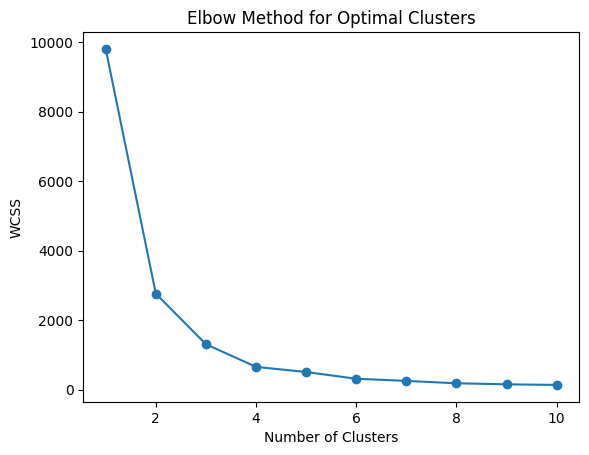

In [39]:
wcss = []  # Within-cluster sum of squares
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(users[["R_normalized", "F_normalized", "M_normalized"]])
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal Clusters")
plt.show()

        country    R    F            M  user_id  R_normalized  F_normalized  \
0            25    4    6    47.586667   180357      0.003653      0.000558   
1            25    6    3    17.948750   180350      0.005479      0.000279   
2            25    0  195    75.791337   180360      0.000000      0.018133   
3             8  178    1  1799.000000   175467      0.162557      0.000093   
4            25   39   48    58.717963   175467      0.035616      0.004463   
...         ...  ...  ...          ...      ...           ...           ...   
577489       25   19   23    84.161250   534283      0.017352      0.002139   
577490       25   19   31    36.156341   453264      0.017352      0.002883   
577491       25   47   12    25.498235   154065      0.042922      0.001116   
577492       25    0   93    29.134425   154041      0.000000      0.008648   
577493       25   25   24    28.788621    17697      0.022831      0.002232   

        M_normalized    segment  
0       1.641939e

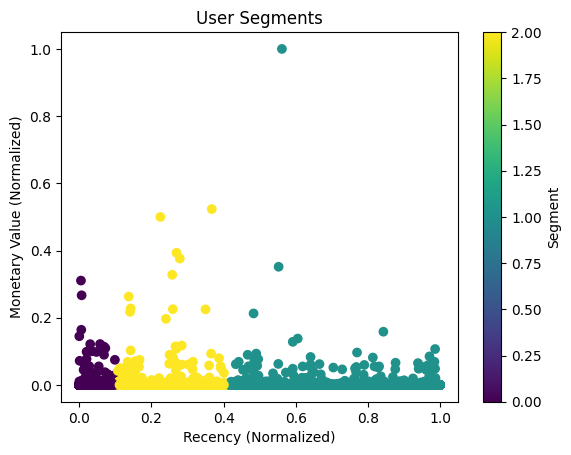

In [40]:
# Based on the elbow point, choose the number of clusters (manually select after visual inspection)
optimal_clusters = 3 

# Apply K-Means clustering with the chosen number of clusters
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
users["segment"] = kmeans.fit_predict(users[["R_normalized", "F_normalized", "M_normalized"]])

# Map cluster labels to segment names (e.g., loyal, at-risk, etc.)
segment_names = {0: "Loyal", 1: "At-Risk", 2: "Potential"}  # Adjust names as needed
users["segment"] = users["segment"].map(segment_names)

# Display results
print(users)

# Visualize the segments (optional)
plt.scatter(users["R_normalized"], users["M_normalized"], c=kmeans.labels_, cmap="viridis")
plt.xlabel("Recency (Normalized)")
plt.ylabel("Monetary Value (Normalized)")
plt.title("User Segments")
plt.colorbar(label="Segment")
plt.show()

---

#### Train
- `session_id`: Session identifier.
- `date`: Interaction date.
- `timestamp_local`: Interaction timestamp.
- `user_id`: User identifier.
- `country`: Country identifier.
- `partnumber`: Product identifier with which the interaction occurred.
- `device_type`: Type of device used.
- `pagetype`: Type of page where the interaction occurred within the e-commerce site.
- `add_to_cart`: Boolean indicating if the interaction was adding to the cart. This variable won't be available in the test dataset.

In [27]:
# Load and see dataset
train = pd.read_csv(train_path)
train.head()

,session_id,date,timestamp_local,add_to_cart,user_id,country,partnumber,device_type,pagetype
0,64,2024-06-06,2024-06-06 16:43:17.389,0,NaN,29,14327,1,24.0
1,117,2024-06-08,2024-06-08 15:11:02.782,0,NaN,57,38422,1,24.0
2,117,2024-06-08,2024-06-08 15:11:44.797,0,NaN,57,19763,1,24.0
3,579,2024-06-05,2024-06-05 19:24:48.397,0,NaN,29,30253,1,24.0
4,1220,2024-06-04,2024-06-04 08:21:13.476,0,480729.0,25,1592,1,24.0


In [32]:
# Check the number of users and sessions in the training set
num_users_train = train['user_id'].nunique()
num_sessions_train = train['session_id'].nunique()

print(f"Number of users in the training set: {num_users_train}")
print(f"Number of sessions in the training set: {num_sessions_train}")

Number of users in the training set: 380052
Number of sessions in the training set: 4573756


In [30]:
# Load trest dataset
test = pd.read_csv(test_path)
test.head()

,session_id,date,timestamp_local,user_id,country,partnumber,device_type,pagetype
0,746,2024-06-15,2024-06-15 18:36:47.390,NaN,57,1254,1,24.0
1,746,2024-06-15,2024-06-15 18:37:04.052,NaN,57,32544,1,24.0
2,746,2024-06-15,2024-06-15 18:37:48.159,NaN,57,12639,1,24.0
3,746,2024-06-15,2024-06-15 18:38:19.899,NaN,57,18048,1,24.0
4,746,2024-06-15,2024-06-15 18:38:46.492,NaN,57,13295,1,24.0


In [31]:
# Check min and max date in train dataset
train_min_date = train['date'].min()
train_max_date = train['date'].max()

print(f"Train dataset - Min date: {train_min_date}, Max date: {train_max_date}")

# Check min and max date in test dataset
test_min_date = test['date'].min()
test_max_date = test['date'].max()

print(f"Test dataset - Min date: {test_min_date}, Max date: {test_max_date}")

Train dataset - Min date: 2024-06-01, Max date: 2024-06-16
Test dataset - Min date: 2024-06-15, Max date: 2024-06-16


In [33]:
# Check the number of users and sessions in the test set
num_users_test = test['user_id'].nunique()
num_sessions_test = test['session_id'].nunique()

print(f"Number of users in the testing set: {num_users_test}")
print(f"Number of sessions in the testing set: {num_sessions_test}")

Number of users in the testing set: 1411
Number of sessions in the testing set: 7349


In [34]:
# Group by user_id and count the number of sessions
user_sessions_test = test.groupby('user_id')['session_id'].nunique()

# Filter users with multiple sessions
users_multiple_sessions_test = user_sessions_test[user_sessions_test > 1]

print(f"Number of users with multiple sessions in the test set: {len(users_multiple_sessions_test)}")
print(users_multiple_sessions_test)

Number of users with multiple sessions in the test set: 6
user_id
56512.0     2
177306.0    2
180676.0    2
242263.0    2
270414.0    2
314026.0    2
Name: session_id, dtype: int64


### Split test users

In [45]:
unique_users_train = train['user_id'].unique()

unique_users_test = test['user_id'].unique()
users_not_in_train = test[~test['user_id'].isin(unique_users_train)]
#users_not_in_train.to_csv(os.path.join(data_dir, 'users_not_in_train.csv'), index=False)

# Get user sessions that only have 1 row
single_session_users = users_not_in_train.groupby('session_id').filter(lambda x: len(x) == 1)
single_session_users.to_csv(os.path.join(data_dir, 'new_session_activity_not_in_train.csv'), index=False)
multiple_session_users = users_not_in_train.groupby('session_id').filter(lambda x: len(x) != 1)
multiple_session_users.to_csv(os.path.join(data_dir, 'returning_user_not_in_train.csv'), index=False)

In [47]:
unique_users_train = train['user_id'].unique()
unique_users_test = test['user_id'].unique()

users_in_train = test[test['user_id'].isin(unique_users_train)]
#users_in_train.to_csv(os.path.join(data_dir, 'users_in_train.csv'), index=False)

# Get user sessions that only have 1 row
single_session_users = users_in_train.groupby('session_id').filter(lambda x: len(x) == 1)
single_session_users.to_csv(os.path.join(data_dir, 'new_session_activity_in_train.csv'), index=False)
multiple_session_users = users_in_train.groupby('session_id').filter(lambda x: len(x) != 1)
multiple_session_users.to_csv(os.path.join(data_dir, 'returning_user_in_train.csv'), index=False)

In [46]:
# Find common session_ids between train and test datasets
common_session_ids = set(train['session_id']).intersection(set(test['session_id']))

# Check if there are any common session_ids
if common_session_ids:
  print(f"Number of common session_ids: {len(common_session_ids)}")
  print("Common session_ids:", common_session_ids)
else:
  print("No common session_ids found between train and test datasets.")

No common session_ids found between train and test datasets.
